In [1]:
import os 
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.stats import entropy
import scgen
import seaborn as sns
from scipy import stats
import matplotlib
import scipy.sparse as sparse
from scgen.file_utils import ensure_dir
matplotlib.rc('ytick', labelsize=14)
matplotlib.rc('xtick', labelsize=14)
sc.set_figure_params(dpi_save=300)

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
2026-02-15 23:46:29.078701: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 23:46:29.176324: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH:

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
path_to_save = "../results/Figures/Supplemental Figure 6/"
ensure_dir(path_to_save)
sc.settings.figdir = path_to_save

In [3]:
pbmc = scgen.load_file("../data/train_pbmc.h5ad")
pbmc

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 16893 × 6998
    obs: 'condition', 'n_counts', 'n_genes', 'mt_frac', 'cell_type'
    var: 'gene_symbol', 'n_cells'
    uns: 'cell_type_colors', 'condition_colors', 'neighbors'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'distances', 'connectivities'

In [4]:
network = scgen.VAEArith(x_dimension=pbmc.shape[1], z_dimension=100, model_path="../models/scGen/pbmc/CD4T/scgen")
network.restore_model()

2026-02-15 23:46:31.201733: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 23:46:31.219539: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-02-15 23:46:31.219649: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-02-15 23:46:31.219754: W tensorflow/stream_executor/platform/default/

INFO:tensorflow:Restoring parameters from ../models/scGen/pbmc/CD4T/scgen


In [5]:
scgen_reconstructed_hpoly = scgen.load_file("../data/reconstructed/scGen/hpoly.h5ad")
scgen_reconstructed_hpoly

AnnData object with n_obs × n_vars = 7795 × 7000
    obs: 'condition', 'cell_label', 'batch'

In [6]:
scgen_reconstructed_hpoly.obs.groupby(['condition']).size()

/tmp/ipykernel_63821/3478151833.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scgen_reconstructed_hpoly.obs.groupby(['condition']).size()


condition
Endocrine_ctrl                      93
Endocrine_pred_stim                 93
Endocrine_real_stim                 70
Enterocyte.Progenitor_ctrl         466
Enterocyte.Progenitor_pred_stim    466
Enterocyte.Progenitor_real_stim    517
Enterocyte_ctrl                    361
Enterocyte_pred_stim               361
Enterocyte_real_stim               106
Goblet_ctrl                        184
Goblet_pred_stim                   184
Goblet_real_stim                   272
Stem_ctrl                          556
Stem_pred_stim                     556
Stem_real_stim                     492
TA.Early_ctrl                      666
TA.Early_pred_stim                 666
TA.Early_real_stim                 366
TA_ctrl                            357
TA_pred_stim                       357
TA_real_stim                       305
Tuft_ctrl                           53
Tuft_pred_stim                      53
Tuft_real_stim                     195
dtype: int64

In [7]:
scgen_reconstructed_salmonella = scgen.load_file("../data/reconstructed/scGen/salmonella.h5ad")
scgen_reconstructed_salmonella

AnnData object with n_obs × n_vars = 7024 × 7000
    obs: 'condition', 'cell_label', 'batch'

In [8]:
scgen_reconstructed_salmonella.obs.groupby(['condition']).size()

/tmp/ipykernel_63821/2592540541.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scgen_reconstructed_salmonella.obs.groupby(['condition']).size()


condition
Endocrine_ctrl                      98
Endocrine_pred_stim                 98
Endocrine_real_stim                 62
Enterocyte.Progenitor_ctrl         466
Enterocyte.Progenitor_pred_stim    466
Enterocyte.Progenitor_real_stim    198
Enterocyte_ctrl                    367
Enterocyte_pred_stim               367
Enterocyte_real_stim               594
Goblet_ctrl                        190
Goblet_pred_stim                   190
Goblet_real_stim                   103
Stem_ctrl                          570
Stem_pred_stim                     570
Stem_real_stim                     174
TA.Early_ctrl                      676
TA.Early_pred_stim                 676
TA.Early_real_stim                 250
TA_ctrl                            350
TA_pred_stim                       350
TA_real_stim                        95
Tuft_ctrl                           48
Tuft_pred_stim                      48
Tuft_real_stim                      18
dtype: int64

In [9]:
def score(adata, data_name, n_deg=10, n_genes=1000, condition_key="condition", cell_type_key="cell_type",
          conditions={"stim": "stimulated", "ctrl": "control"},
          sortby="median_score"):
    sc.tl.rank_genes_groups(adata, groupby=condition_key, method="wilcoxon", n_genes=n_genes)
    gene_names_up = adata.uns["rank_genes_groups"]['names'][conditions['stim']]
    gene_names_down = adata.uns["rank_genes_groups"]['names'][conditions['ctrl']]
    gene_lfcs_up = adata.uns["rank_genes_groups"]['logfoldchanges'][conditions['stim']]
    gene_lfcs_down = adata.uns["rank_genes_groups"]['logfoldchanges'][conditions['ctrl']]

    gene_names = gene_names_up.tolist()[:n_genes // 2] + gene_names_down.tolist()[:n_genes // 2]
    gene_lfcs = gene_lfcs_up.tolist()[:n_genes // 2] + gene_lfcs_down.tolist()[:n_genes // 2]
    diff_genes_df = pd.DataFrame({"names": gene_names, "lfc": gene_lfcs})
    diff_genes = diff_genes_df["names"].tolist()
    print(len(diff_genes))
    adata_deg = adata[:, diff_genes].copy()
    cell_types = adata_deg.obs[cell_type_key].cat.categories.tolist()
    lfc_temp = np.zeros((len(cell_types), n_genes))
    for j, ct in enumerate(cell_types):
        if cell_type_key == "cell_type":  # if data is pbmc
            stim = adata_deg[(adata_deg.obs[cell_type_key] == ct) &
                             (adata_deg.obs[condition_key] == conditions["stim"])].X.mean(0).A1
            ctrl = adata_deg[(adata_deg.obs[cell_type_key] == ct) &
                             (adata_deg.obs[condition_key] == conditions["ctrl"])].X.mean(0).A1
        else:
            stim = adata_deg[(adata_deg.obs[cell_type_key] == ct) &
                             (adata_deg.obs[condition_key] == conditions["stim"])].X.mean(0)
            ctrl = adata_deg[(adata_deg.obs[cell_type_key] == ct) &
                             (adata_deg.obs[condition_key] == conditions["ctrl"])].X.mean(0)
        lfc_temp[j] = np.abs((stim - ctrl)[None, :])
    norm_lfc = lfc_temp / lfc_temp.sum(0).reshape((1, n_genes))
    ent_scores = entropy(norm_lfc)
    median = np.median(lfc_temp, axis=0)
    med_scores = np.max(np.abs((lfc_temp - median)), axis=0)
    df_score = pd.DataFrame({"genes": adata_deg.var_names.tolist(), "median_score": med_scores,
                             "entropy_score": ent_scores})
    if sortby == "median_score":
        print(df_score.sort_values(by=['median_score'], ascending=False))
        return df_score.sort_values(by=['median_score'], ascending=False).iloc[:n_deg, :]
    else:
        return df_score.sort_values(by=['entropy_score'], ascending=False).iloc[:n_deg, :]

In [12]:
def stacked_violin_plot(recon_data, method, figure, data_name="pbmc", score_type="median_score"):
    if data_name == "pbmc":
        stim_key = "stimulated"
        ctrl_key = "control"
        cell_type_key = "cell_type"
        train = scgen.load_file("../data/train_pbmc.h5ad")
    elif data_name == "hpoly":
        stim_key = "Hpoly.Day10"
        ctrl_key = "Control"
        cell_type_key = "cell_label"
        train = scgen.load_file("../data/train_hpoly.h5ad")
    elif data_name == "salmonella":
        stim_key = "Salmonella"
        ctrl_key = "Control"
        cell_type_key = "cell_label"
        train = scgen.load_file("../data/train_salmonella.h5ad")
    sc.settings.figdir = path_to_save
    conditions = {"ctrl": ctrl_key, "stim": stim_key}

    diff_genes = score(train, data_name, n_deg=10, n_genes=500, cell_type_key=cell_type_key, conditions=conditions,
                       sortby=score_type)
    diff_genes = diff_genes["genes"].tolist()
    
    sc.pl.stacked_violin(recon_data,
                         var_names=diff_genes,
                         groupby="condition",
                         save=f"_{method}_{score_type}_{data_name}.pdf",
                         swap_axes=True,
                         show=True)
    os.rename(src=os.path.join(path_to_save, f"stacked_violin__{method}_{score_type}_{data_name}.pdf"), 
              dst=os.path.join(path_to_save, f"SupplFig6{figure}_{method}_{score_type}_{data_name}.pdf"))

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


500
        genes  median_score  entropy_score
2       Reg3b      1.445777       2.020220
3       Reg3g      1.284191       2.025026
339    Guca2a      1.116699       1.647844
15       Ang4      1.062519       1.895470
11      Itln1      1.043486       1.929974
..        ...           ...            ...
138     Defa3      0.032346       2.026902
214     Prom1      0.032278       1.911278
229  Ccdc109b      0.028426       1.750642
476   Slc27a4      0.025429       2.029714
243     Limd2      0.023516       1.470141

[500 rows x 3 columns]


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

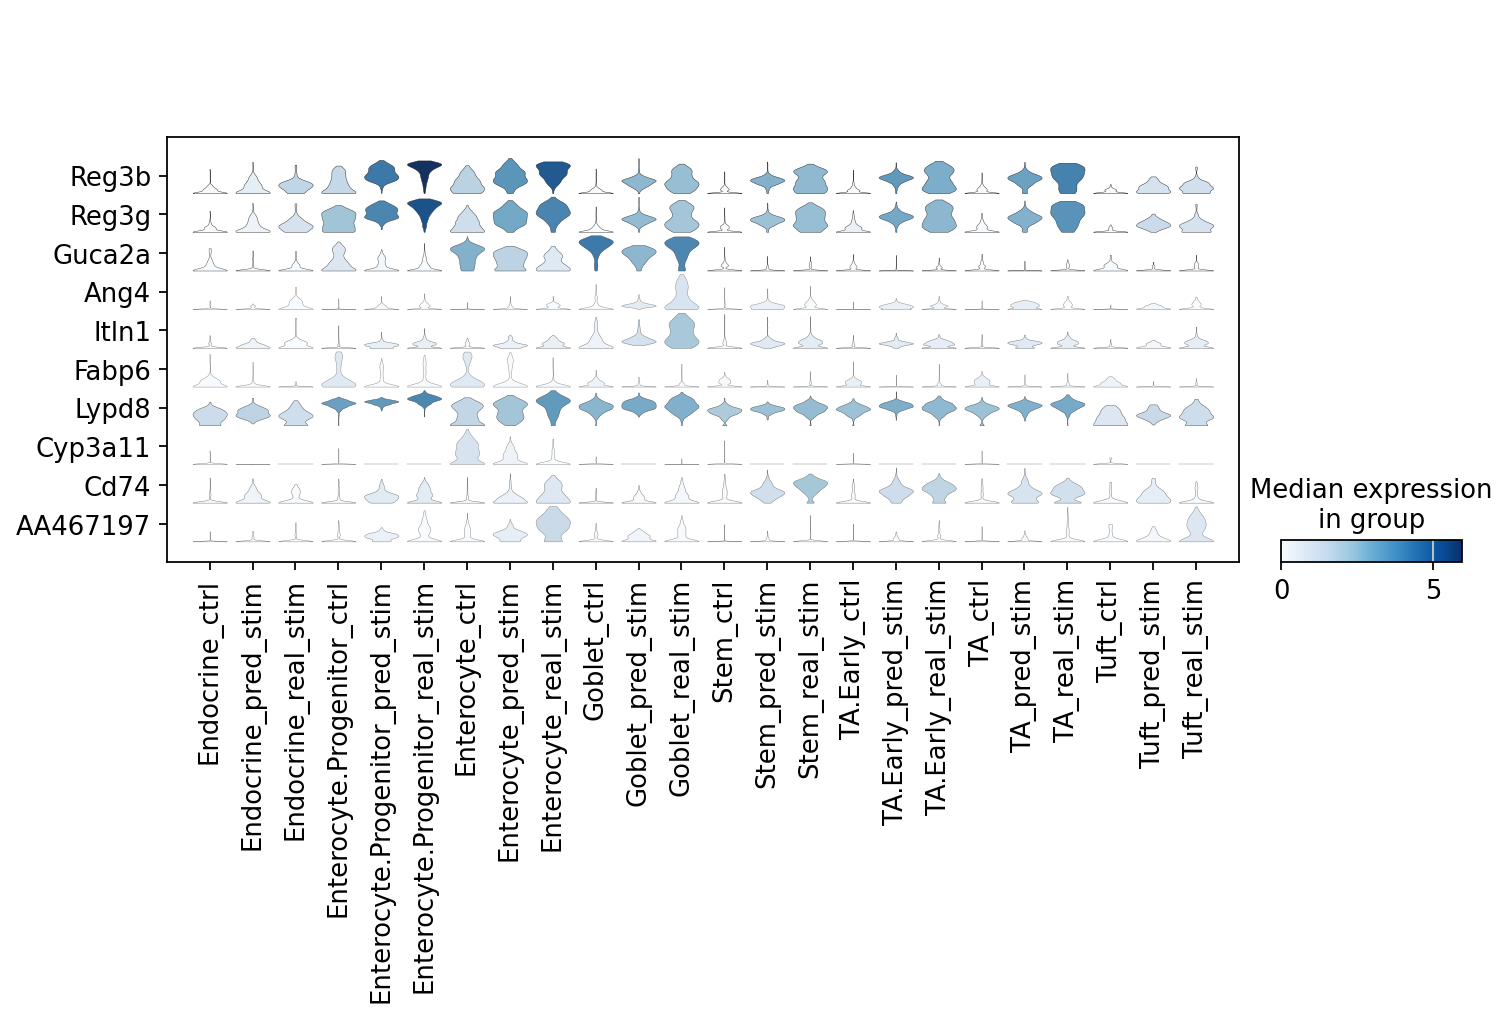

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


500
              genes  median_score  entropy_score
2             Apoa1      1.222406       1.948721
43              Sst      1.070338       1.764564
0             Reg3b      1.021918       2.072936
96             Cd74      0.837238       1.791013
50           H2.Ab1      0.774975       1.695697
..              ...           ...            ...
491  X2510002D24Rik      0.025204       2.042045
124            Mpp1      0.025014       1.816387
467          Polr2h      0.024341       1.970967
227            Mall      0.022242       1.757699
176          Cyp4v3      0.019480       2.025686

[500 rows x 3 columns]


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

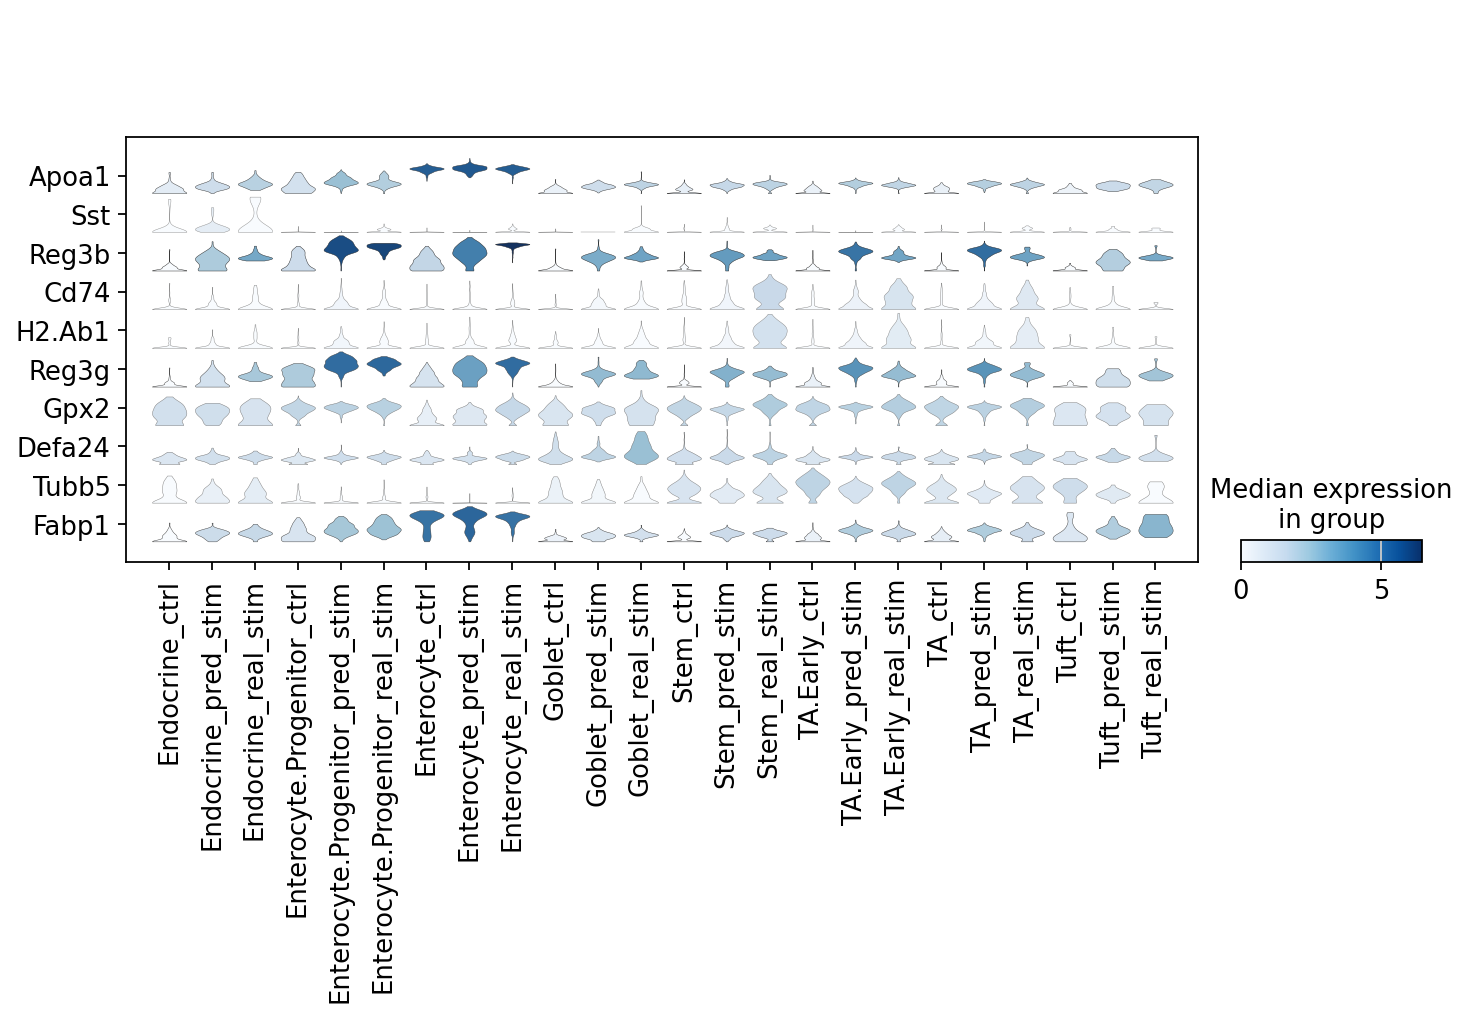

In [13]:
stacked_violin_plot(scgen_reconstructed_hpoly, "scGen", "a", "hpoly", "median_score")
stacked_violin_plot(scgen_reconstructed_salmonella, "scGen", "b", "salmonella", "median_score")